# EDA

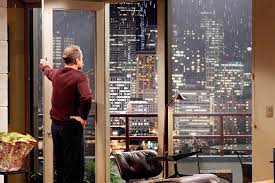

In [202]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {"figure.figsize": (8, 5), "axes.facecolor": "white", "axes.edgecolor": "black"}
)
plt.rcParams["figure.facecolor"] = "w"
pd.plotting.register_matplotlib_converters()
pd.set_option("display.float_format", lambda x: "%.3f" % x)

In [203]:
import pandas as pd
df_import = pd.read_csv("data/king_house.csv")
df_import.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
0,7129300520,3.000,1.000,1180.000,5650.000,1.000,NaN,0.000,3,7,...,0.000,1955,0.000,98178,47.511,-122.257,1340.000,5650.000,2014-10-13,221900.000
1,6414100192,3.000,2.250,2570.000,7242.000,2.000,0.000,0.000,3,7,...,400.000,1951,19910.000,98125,47.721,-122.319,1690.000,7639.000,2014-12-09,538000.000
2,5631500400,2.000,1.000,770.000,10000.000,1.000,0.000,0.000,3,6,...,0.000,1933,NaN,98028,47.738,-122.233,2720.000,8062.000,2015-02-25,180000.000
3,2487200875,4.000,3.000,1960.000,5000.000,1.000,0.000,0.000,5,7,...,910.000,1965,0.000,98136,47.521,-122.393,1360.000,5000.000,2014-12-09,604000.000
4,1954400510,3.000,2.000,1680.000,8080.000,1.000,0.000,0.000,3,8,...,0.000,1987,0.000,98074,47.617,-122.045,1800.000,7503.000,2015-02-18,510000.000


In [204]:
df_import["waterfront"].unique()
df_import["waterfront"].isna().sum()

np.int64(2391)

In [205]:
df_import["waterfront"].unique()


array([nan,  0.,  1.])

Need to decide whether to deleted or put 0 for waterfront value.

In [206]:
len(df_import)

21597

In [207]:
df_import["id"].duplicated().sum()


np.int64(177)

In [208]:
duplicates = df_import[df_import["id"].duplicated(keep=False)]
duplicates.sort_values("id")


,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
2495,1000102,6.000,3.000,2400.000,9373.000,2.000,NaN,0.000,3,7,...,0.000,1991,0.000,98002,47.326,-122.214,2060.000,7316.000,2015-04-22,300000.000
2494,1000102,6.000,3.000,2400.000,9373.000,2.000,NaN,0.000,3,7,...,0.000,1991,0.000,98002,47.326,-122.214,2060.000,7316.000,2014-09-16,280000.000
16800,7200179,2.000,1.000,840.000,12750.000,1.000,0.000,0.000,3,6,...,0.000,1925,NaN,98055,47.484,-122.211,1480.000,6969.000,2014-10-16,150000.000
16801,7200179,2.000,1.000,840.000,12750.000,1.000,0.000,0.000,3,6,...,0.000,1925,NaN,98055,47.484,-122.211,1480.000,6969.000,2015-04-24,175000.000
11422,109200390,3.000,1.750,1480.000,3900.000,1.000,0.000,0.000,4,7,...,0.000,1980,0.000,98023,47.298,-122.367,1830.000,6956.000,2014-10-20,250000.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6339,9828200460,2.000,1.000,700.000,4800.000,1.000,0.000,0.000,3,7,...,0.000,1922,0.000,98122,47.615,-122.300,1440.000,4800.000,2014-06-27,260000.000
15186,9834200305,3.000,1.000,1790.000,3876.000,1.500,0.000,0.000,5,7,...,700.000,1904,0.000,98144,47.575,-122.288,1360.000,4080.000,2015-02-10,615000.000
15185,9834200305,3.000,1.000,1790.000,3876.000,1.500,0.000,0.000,5,7,...,700.000,1904,0.000,98144,47.575,-122.288,1360.000,4080.000,2014-07-16,350000.000
1084,9834200885,4.000,2.500,2080.000,4080.000,1.000,0.000,0.000,5,7,...,1040.000,1962,0.000,98144,47.572,-122.290,1340.000,4080.000,2014-07-17,360000.000


Price changes for duplicates rows so take latest price based on dates.
Need to decide whether to deleted or put 0 for waterfront value. Decided to ampute missing values of waterfront to 0


In [209]:
type(df_import["date"].unique()[0])

str

Deleting duplicate rows based on ids and keep rows with latest date.

In [210]:
df_import["date"] = pd.to_datetime(df_import["date"])

df = (
    df_import.sort_values("date")
      .drop_duplicates(subset="id", keep="last")
)
df.head()
len(df)

21420

In [211]:
df_import["waterfront"] = df_import["waterfront"].fillna(0)

In [212]:
df_import.shape

(21597, 21)

In [213]:
df_import.isna().sum()

id                  0
bedrooms            0
bathrooms           0
sqft_living         0
sqft_lot            0
floors              0
waterfront          0
view               63
condition           0
grade               0
sqft_above          0
sqft_basement     452
yr_built            0
yr_renovated     3848
zipcode             0
lat                 0
long                0
sqft_living15       0
sqft_lot15          0
date                0
price               0
dtype: int64

In [214]:
df_import["sqft_basement"].isna()


0        False
1        False
2        False
3        False
4        False
         ...  
21592    False
21593    False
21594    False
21595    False
21596    False
Name: sqft_basement, Length: 21597, dtype: bool

In [215]:
df_import["yr_renovated"].isna()


0        False
1        False
2         True
3        False
4        False
         ...  
21592    False
21593    False
21594    False
21595    False
21596    False
Name: yr_renovated, Length: 21597, dtype: bool

In [216]:
df_import["view"].isna()


0        False
1        False
2        False
3        False
4        False
         ...  
21592    False
21593    False
21594    False
21595    False
21596    False
Name: view, Length: 21597, dtype: bool

deleting rows with missing values


In [217]:
df_final = df_import.dropna()
len(df_final)


17335

In [218]:
df_final.columns

Index(['id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'date', 'price'],
      dtype='str')

In [219]:
df_final["waterfront"].value_counts()

waterfront
0.000    17219
1.000      116
Name: count, dtype: int64

<Axes: xlabel='waterfront'>

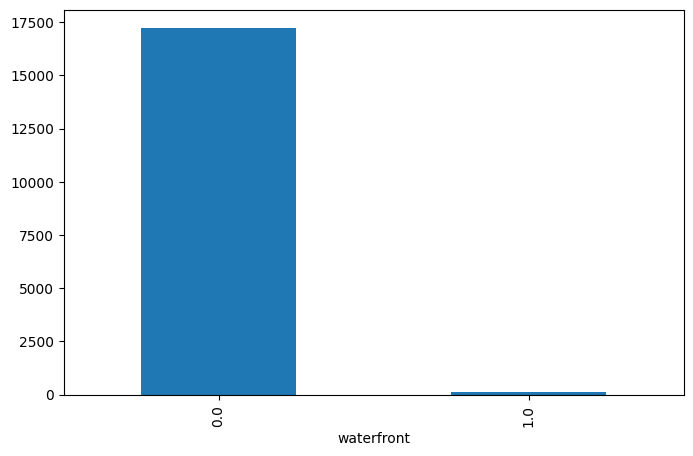

In [220]:
df_final["waterfront"].value_counts().plot(kind="bar")

In [221]:
df_final.groupby("waterfront")["price"].describe()

,count,mean,std,min,25%,50%,75%,max
waterfront,,,,,,,,
0.000,17219.000,532944.186,343428.724,80000.000,320000.000,450000.000,640000.000,7700000.000
1.000,116.000,1723141.379,1182603.103,285000.000,785000.000,1485000.000,2325000.000,7060000.000


In [222]:
df_final[["price", "waterfront"]].head()

,price,waterfront
0,221900.000,0.000
1,538000.000,0.000
3,604000.000,0.000
4,510000.000,0.000
5,1230000.000,0.000


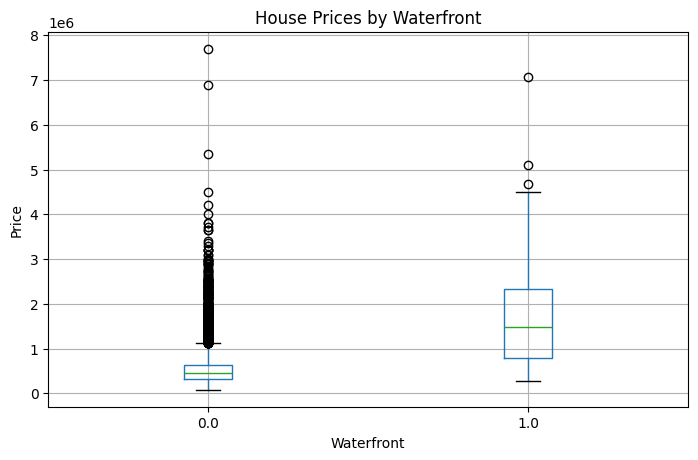

In [223]:
df_final.boxplot(column="price", by="waterfront")

plt.xlabel("Waterfront")
plt.ylabel("Price")
plt.title("House Prices by Waterfront")
plt.suptitle("")
plt.show()

In [224]:
df_final.groupby("waterfront")["price"].agg(
    count="count",
    mean="mean",
    median="median"
)

,count,mean,median
waterfront,,,
0.000,17219,532944.186,450000.000
1.000,116,1723141.379,1485000.000


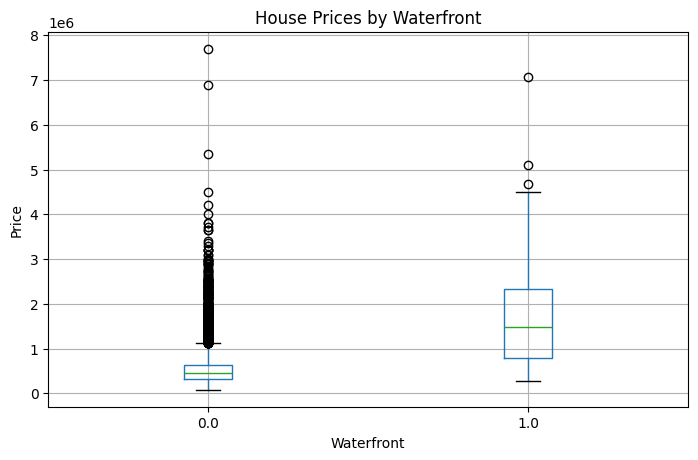

In [225]:
import matplotlib.pyplot as plt

df_final.boxplot(column="price", by="waterfront")

plt.xlabel("Waterfront")
plt.ylabel("Price")
plt.title("House Prices by Waterfront")
plt.suptitle("")
plt.show()

In [226]:
waterfront_houses = df_final[df_final["waterfront"] == 1]

In [227]:
waterfront_houses[["waterfront", "price"]]

,waterfront,price
49,1.000,1350000.000
230,1.000,655000.000
246,1.000,2400000.000
264,1.000,369900.000
300,1.000,3080000.000
...,...,...
19968,1.000,1900000.000
20309,1.000,3000000.000
20751,1.000,2300000.000
21185,1.000,2230000.000


In [228]:
waterfront_houses[["waterfront", "price"]]

,waterfront,price
49,1.000,1350000.000
230,1.000,655000.000
246,1.000,2400000.000
264,1.000,369900.000
300,1.000,3080000.000
...,...,...
19968,1.000,1900000.000
20309,1.000,3000000.000
20751,1.000,2300000.000
21185,1.000,2230000.000


In [229]:
waterfront_houses["price"].describe()

count       116.000
mean    1723141.379
std     1182603.103
min      285000.000
25%      785000.000
50%     1485000.000
75%     2325000.000
max     7060000.000
Name: price, dtype: float64

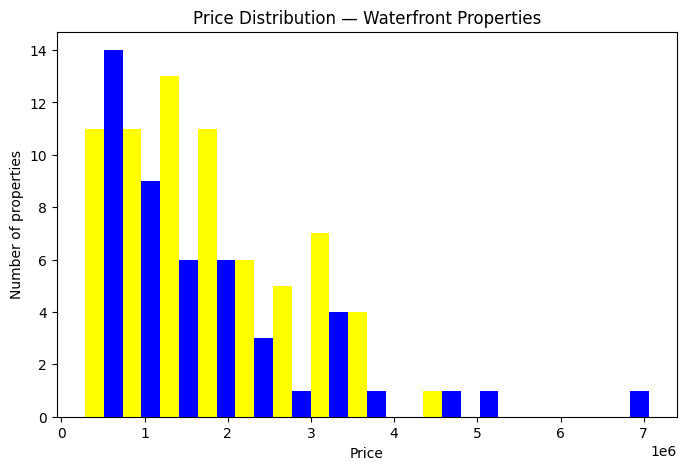

In [231]:
import matplotlib.pyplot as plt

counts, bins, patches = plt.hist(
    waterfront_houses["price"],
    bins=30
)

# Alternate yellow and blue
for i, patch in enumerate(patches):
    patch.set_facecolor("yellow" if i % 2 == 0 else "blue")

plt.xlabel("Price")
plt.ylabel("Number of properties")
plt.title("Price Distribution — Waterfront Properties")
plt.show()

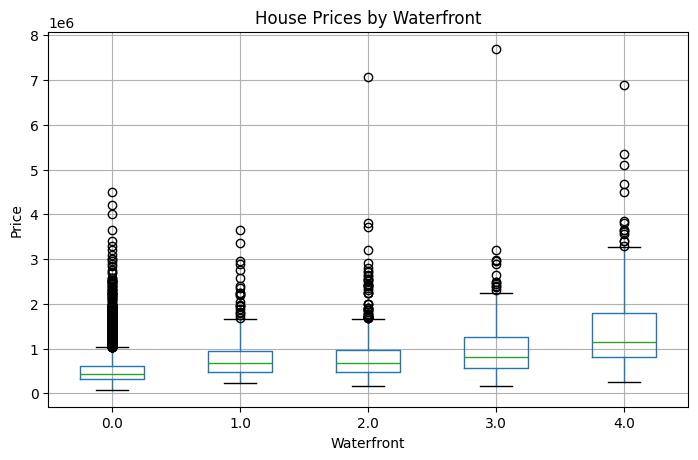

In [234]:
import matplotlib.pyplot as plt

df_final.boxplot(column="price", by="view")

plt.xlabel("Waterfront")
plt.ylabel("Price")
plt.title("House Prices by Waterfront")
plt.suptitle("")
plt.show()

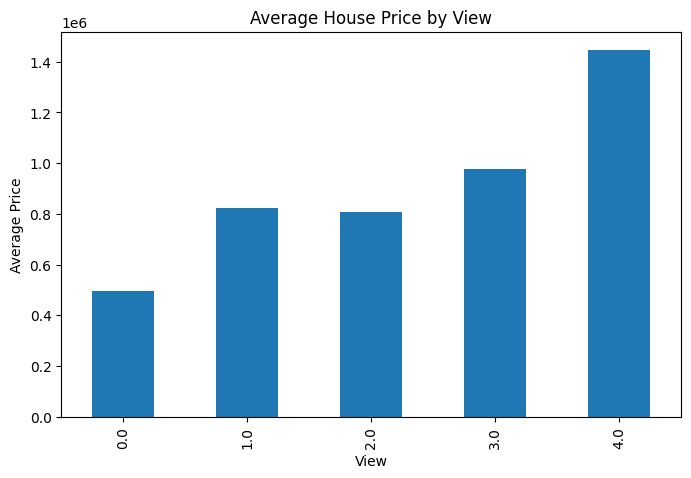

In [235]:
df_final.groupby("view")["price"].mean().plot(kind="bar")

plt.xlabel("View")
plt.ylabel("Average Price")
plt.title("Average House Price by View")
plt.show()

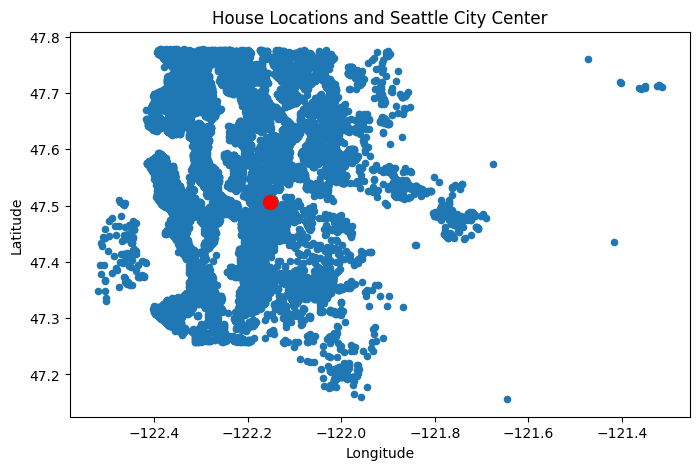

In [241]:

center_lat = 47.5062
center_long = -122.1521
df_final.plot.scatter(x="long", y="lat")

plt.scatter(center_long, center_lat, color="red", s=100)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("House Locations and Seattle City Center")
plt.show()

In [4]:
from geopy.distance import geodesic

def distance_from_center(row):
    return geodesic(
        (row["lat"], row["long"]),
        (center_lat, center_long)
    ).km

df_final["distance_center_km"] = df_final.apply(
    distance_from_center,
    axis=1
)

ModuleNotFoundError: No module named 'geopy'